In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hence Proved — 01 — Newton's Second Law
## F = ma | Linear Regression | Feature Engineering
**Author:** Spoorthy J  
**Date:** 1st May 2026  
**Series:** Hence Proved — Physics through Machine Learning

## Problem Statement
Can a machine rediscover Newton's Second Law
from raw numbers alone

## Physics Context
Newton's Second Law — F = ma

| Variable | Meaning | Unit |
|---|---|---|
| m | Mass | kg |
| a | Acceleration | m/s² |
| F | Force (target) | N |

Key insight — F is a multiplicative relationship,
not additive. Linear Regression cannot learn
multiplication directly. Feature engineering required.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

np.random.seed(42)

In [ ]:
n=100

# Mass in kg — everyday objects, 1kg to 100kg
mass = np.round(np.random.uniform(1, 100, n), 2)

# Acceleration in m/s² — gentle push to aggressive thrust
acceleration = np.round(np.random.uniform(0.5, 20, n), 2)

# F = ma — pure physics, with tiny real-world noise
noise = np.random.normal(0, 5, n)
force = np.round((mass * acceleration) + noise, 2)

In [ ]:
#Converting the data to DataFrame
df = pd.DataFrame({
    'mass': mass,
    'acceleration': acceleration,
    'force': force
})

df.head()
df.describe()

,mass,acceleration,force
count,100.000000,100.000000,100.000000
mean,47.548200,10.207900,480.230200
std,29.451668,5.715826,424.033062
min,1.550000,0.640000,8.890000
25%,20.125000,5.220000,141.890000
50%,46.950000,10.360000,346.820000
75%,73.290000,15.440000,708.150000
max,98.700000,19.720000,1827.140000


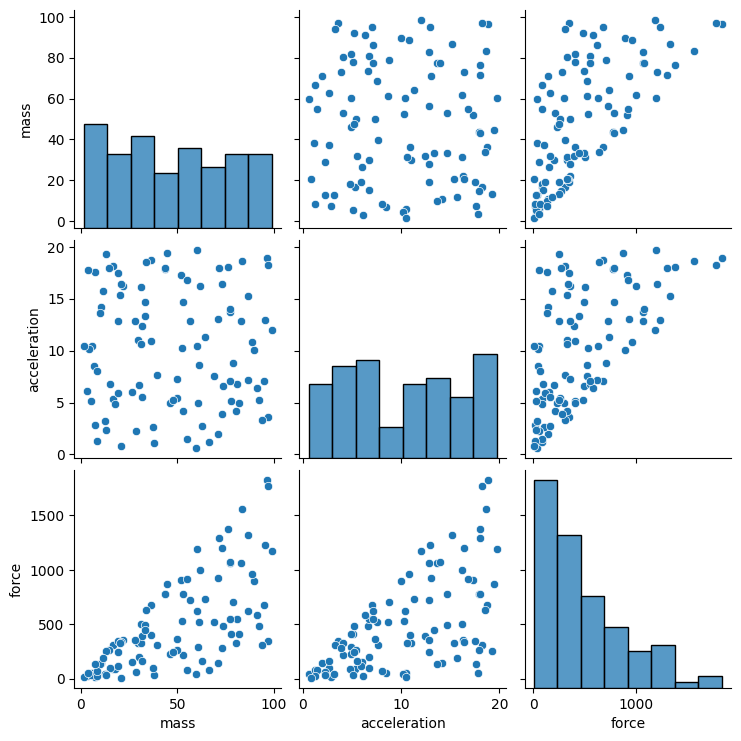

In [ ]:
#EDA

sns.pairplot(df)
plt.show()

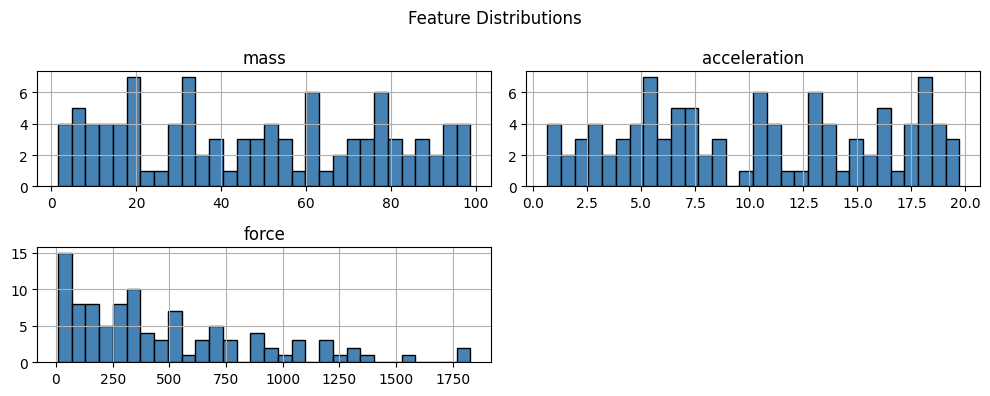

In [ ]:
# Distributions
df.hist(figsize=(10, 4), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation
df.corr(numeric_only=True)

,mass,acceleration,force
mass,1.000000,-0.034066,0.683384
acceleration,-0.034066,1.000000,0.601130
force,0.683384,0.601130,1.000000


In [ ]:
# Training the model
# Step 01 - Blindly using linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop('force', axis=1)
y = df['force']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("Mean squared Error :: ", mean_absolute_error(y_test, y_pred))
print("r2 score :: ", r2_score(y_test, y_pred))

print("\nModel coefficients:")
print(f"  mass_kg         : {model.coef_[0]:.4f}")
print(f"  acceleration_ms2: {model.coef_[1]:.4f}")
print(f"  intercept       : {model.intercept_:.4f}")

Mean squared Error ::  136.50098160938936
r2 score ::  0.8585703255734354

Model coefficients:
  mass_kg         : 10.3498
  acceleration_ms2: 47.4067
  intercept       : -499.8799


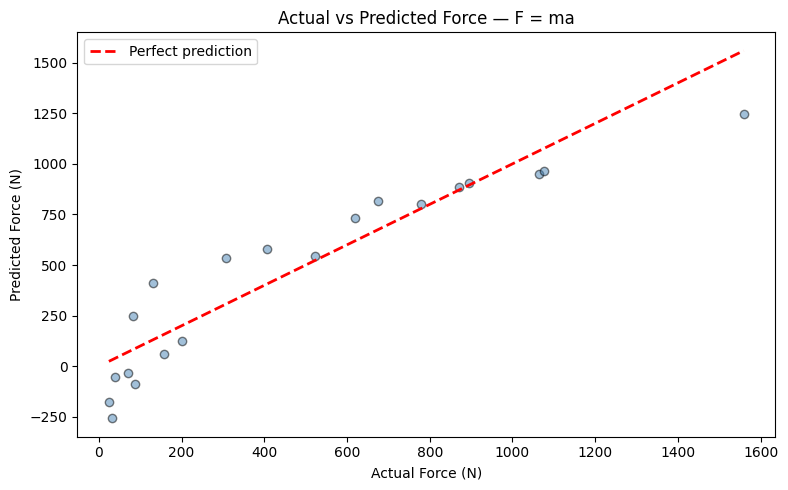

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Force (N)")
plt.ylabel("Predicted Force (N)")
plt.title("Actual vs Predicted Force — F = ma")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# What the model predicts vs actual physics
sample_mass = 50        # kg
sample_acc = 10         # m/s²

actual_force = sample_mass * sample_acc
model_force = (10.35 * sample_mass) + (47.41 * sample_acc) + (-499.88)

print(f"Actual F=ma          : {actual_force} N")
print(f"Model prediction     : {model_force:.2f} N")
print(f"Error                : {abs(actual_force - model_force):.2f} N")

Actual F=ma          : 500 N
Model prediction     : 491.72 N
Error                : 8.28 N


# Second iteration - introducing a new column. Multiplication of mass and acceleration.

In [ ]:
# Fix the model by trying other methods, considering the physics POV
"""
As the physics' 2nd law of motion says F = ma, hence tryin to create m*a
column in the dataframe.
"""

df["mass_X_acceleration"] = df["mass"] * df["acceleration"]

X_2 = df.drop('force', axis=1)
y_2 = df['force']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [ ]:
model_2 = LinearRegression()
model_2.fit(X_train2, y_train2)

y_pred2 = model_2.predict(X_test2)

print("Mean absolute error :: ", mean_absolute_error(y_test2, y_pred2))
print("r2 score :: ", r2_score(y_test2, y_pred2))
print("model - 2 coefficent :: ", model_2.coef_[0])
print("model - 2 intercept :: ", model_2.intercept_)

Mean absolute error ::  3.6758131245214223
r2 score ::  0.9999106333673534
model - 2 coefficent ::  -0.023223162320425955
model - 2 intercept ::  -0.6109071232591532


# Third iteration - dropping the individual mass and acceleration columns and training the model

In [ ]:


X_3 = df[['mass_X_acceleration']]
y_3 = df['force']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)
model_3 = LinearRegression()
model_3.fit(X_train3, y_train3)

y_pred3 = model_3.predict(X_test3)

print("mean absolute error :: ", mean_absolute_error(y_test3, y_pred3))
print("r2 score :: ", r2_score(y_test3, y_pred3))
print("Coeffecient :: ", model_3.coef_[0])
print("Intercept :: ", model_3.intercept_)

mean absolute error ::  3.7776528455288068
r2 score ::  0.9999029779534956
Coeffecient ::  1.0011541829366397
Intercept ::  -0.18695694742928026


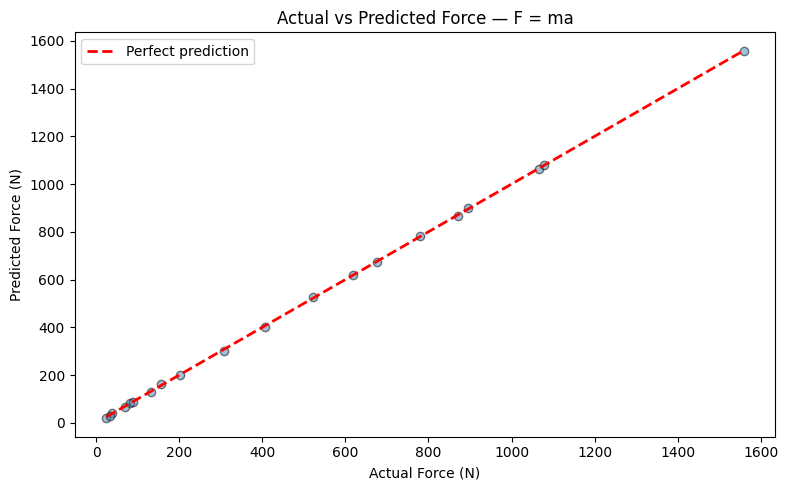

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test3, y_pred3, alpha=0.5, color='steelblue', edgecolors='black')
plt.plot([y_test3.min(), y_test3.max()],
         [y_test3.min(), y_test3.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Force (N)")
plt.ylabel("Predicted Force (N)")
plt.title("Actual vs Predicted Force — F = ma")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

| Model | Features | R² | MAE | Insight |
|---|---|---|---|---|
| Model 1 | m, a separately | 0.8585 | 136.5 N | Cannot learn multiplication |
| Model 2 | m, a, m×a | 0.9999 | 3.67 N | Works but noisy coefficients |
| Model 3 | m×a only | 0.9999 | 3.77 N | Clean proof — F = ma rediscovered |

**Coefficient : 1.0011 → F = 1.0 × (m×a) + 0**

F = ma. Hence Proved. ✓